# DINOv2/v3 视频分割跟踪 - CPU 测试版

本 notebook 演示如何使用 DINO 特征进行视频分割跟踪。

**原理：** 给定第一帧的分割遮罩，使用 patch 相似度将标签传播到所有帧。

**关于模型访问：**
- **DINOv2**: 公开可用，无需申请（本 notebook 使用）
- **DINOv3**: 需要申请权限 → [申请地址](https://ai.meta.com/resources/models-and-libraries/dinov3-downloads/)

**适用环境：**
- AMD Ryzen CPU (无 CUDA)
- 32GB 内存
- 简化版：处理少量帧以加快演示

## 1. 环境配置

In [16]:
import io
import os
import tarfile
import urllib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from transformers import AutoModel, AutoImageProcessor

print(f"PyTorch 版本: {torch.__version__}")
print(f"使用设备: CPU")

PyTorch 版本: 2.10.0+cpu
使用设备: CPU


## 2. 加载模型

In [ ]:
# # 使用 Hugging Face DINOv2 (公开可用)
# HF_MODEL = 'facebook/dinov2-small'

# print(f"正在加载模型: {HF_MODEL}")

# processor = AutoImageProcessor.from_pretrained(HF_MODEL)
# model = AutoModel.from_pretrained(HF_MODEL)
# model.eval()

REPO_DIR = r'd:\AI\Git\dinov3.git'

# 轻量模型
# WEIGHTS_PATH = 'dinov3_vits16_pretrain_lvd1689m-08c60483.pth'  # 申请后获得的权重
# Model_ID='dinov3_vits16'

# 高等第一档
WEIGHTS_PATH = 'notebook\dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth'
Model_ID='dinov3_vitl16'

model = torch.hub.load(
    repo_or_dir=REPO_DIR,
    model=Model_ID,
    source='local',
    weights=WEIGHTS_PATH
)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
# 特征维度会在后续动态获取
PATCH_SIZE = 16

print(f"✓ 模型加载完成! 参数量: {total_params / 1e6:.1f}M")
print(f"注意: 特征维度将在特征提取时动态确定")

## 3. 加载视频帧

加载示例视频帧和第一帧的分割遮罩。

In [18]:
# 本地视频帧路径
LOCAL_VIDEO_FRAMES_DIR = r"D:\AI\Datasets\video_frames"

def load_video_frames_from_local(frame_dir: str) -> list:
    """从本地目录加载视频帧"""
    import glob
    import re
    
    # 获取所有 jpg 文件
    frame_files = sorted(glob.glob(os.path.join(frame_dir, "*.jpg")))
    
    images = []
    for frame_file in frame_files:
        image = Image.open(frame_file).convert("RGB")
        images.append(image)
    
    return images

print(f"正在从本地加载视频帧: {LOCAL_VIDEO_FRAMES_DIR}")
frames = load_video_frames_from_local(LOCAL_VIDEO_FRAMES_DIR)
num_frames = len(frames)

# 为了加快 CPU 演示，只处理部分帧
MAX_FRAMES = 20  # CPU 测试用较少帧
frame_indices = np.linspace(0, num_frames - 1, MAX_FRAMES, dtype=int)
frames = [frames[i] for i in frame_indices]
num_frames = len(frames)

print(f"✓ 加载了 {num_frames} 帧 (原始 {num_frames} 帧，采样后 {num_frames} 帧)")
print(f"帧尺寸: {frames[0].size}")

正在从本地加载视频帧: D:\AI\Datasets\video_frames
✓ 加载了 20 帧 (原始 20 帧，采样后 20 帧)
帧尺寸: (1920, 1440)


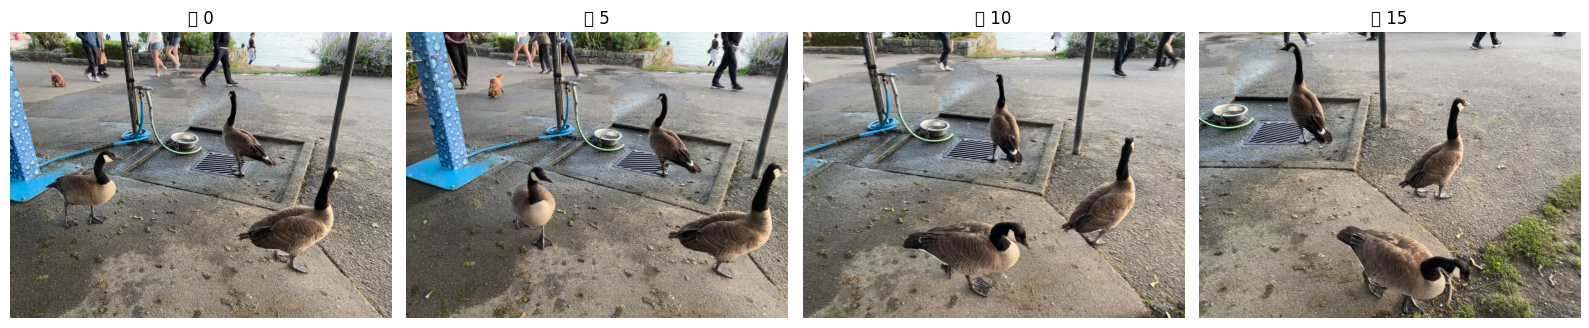

In [19]:
# 显示部分帧
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    frame_idx = i * (num_frames // 4)
    axes[i].imshow(frames[frame_idx])
    axes[i].set_title(f"帧 {frame_idx}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 4. 加载第一帧遮罩

从本地加载第一帧遮罩: D:\AI\Git\dinov3.git\notebooks\first_video_frame_mask.png
遮罩尺寸: (1440, 1920)
目标数量: 6


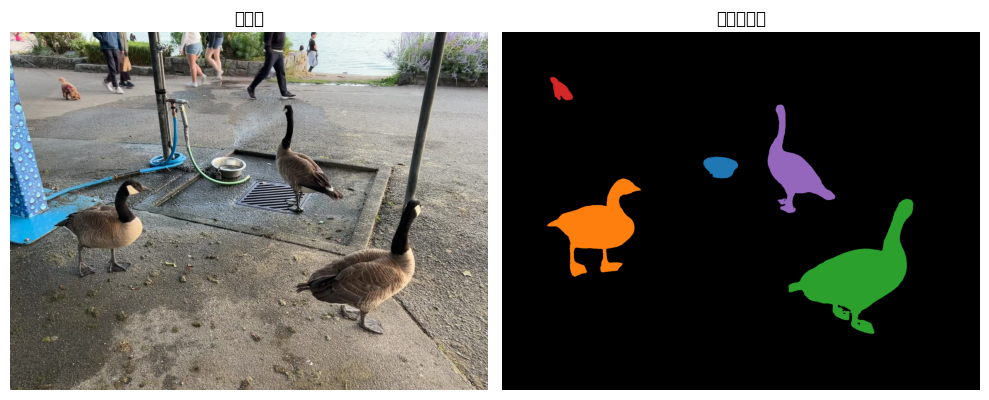

In [20]:
def mask_to_rgb(mask: np.ndarray, num_masks: int) -> np.ndarray:
    """将遮罩转换为 RGB 可视化"""
    background = mask == 0
    mask_norm = mask - 1
    num_colors = num_masks - 1
    
    if num_colors <= 10:
        mask_rgb = plt.get_cmap("tab10")(mask_norm)[..., :3]
    elif num_colors <= 20:
        mask_rgb = plt.get_cmap("tab20")(mask_norm)[..., :3]
    else:
        mask_rgb = plt.get_cmap("gist_rainbow")(mask_norm / (num_colors - 1))[..., :3]
    
    mask_rgb = (mask_rgb * 255).astype(np.uint8)
    mask_rgb[background, :] = 0
    return mask_rgb

# 本地遮罩路径
LOCAL_MASK_PATH = r"D:\AI\Git\dinov3.git\notebooks\first_video_frame_mask.png"

print(f"从本地加载第一帧遮罩: {LOCAL_MASK_PATH}")
first_mask_np = np.array(Image.open(LOCAL_MASK_PATH))

num_masks = int(first_mask_np.max() + 1)
print(f"遮罩尺寸: {first_mask_np.shape}")
print(f"目标数量: {num_masks}")

# 显示
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(frames[0])
axes[0].set_title("第一帧")
axes[0].axis('off')
axes[1].imshow(mask_to_rgb(first_mask_np, num_masks))
axes[1].set_title("第一帧遮罩")
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 5. 设置变换

确定处理尺寸和测试模型输出。

In [ ]:
# 图像预处理参数
PATCH_SIZE = 16
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# CPU 测试用较小的分辨率，但比之前大一些以保留更多细节
# 原始版本使用 960 短边，我们用 384 以平衡速度和效果
SHORT_SIDE = 384

import math

class ResizeToMultiple:
    """调整图像大小，保持宽高比，并确保是 patch_size 的倍数"""
    def __init__(self, short_side: int, multiple: int):
        self.short_side = short_side
        self.multiple = multiple

    def _round_up(self, side: float) -> int:
        return math.ceil(side / self.multiple) * self.multiple

    def __call__(self, img):
        old_width, old_height = img.size
        if old_width > old_height:
            new_height = self._round_up(self.short_side)
            new_width = self._round_up(old_width * new_height / old_height)
        else:
            new_width = self._round_up(self.short_side)
            new_height = self._round_up(old_height * new_width / old_width)
        return TF.resize(img, [new_height, new_width])

def preprocess_image(image_pil):
    """预处理图像为模型输入张量"""
    resize = ResizeToMultiple(SHORT_SIDE, PATCH_SIZE)
    image_resized = resize(image_pil)
    image_tensor = TF.to_tensor(image_resized)
    image_normalized = TF.normalize(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    return image_normalized, image_resized

# 测试模型输出
test_img = Image.new('RGB', (256, 256))
test_tensor, _ = preprocess_image(test_img)
with torch.inference_mode():
    # 使用 get_intermediate_layers 获取特征，与原始 notebook 一致
    outputs = model.get_intermediate_layers(test_tensor.unsqueeze(0), n=1, reshape=True)
    feats = outputs[0]  # [1, D, h, w]

FEATURE_DIM = feats.shape[1]
PATCHES_PER_SIDE_H = feats.shape[2]
PATCHES_PER_SIDE_W = feats.shape[3]
IMAGE_SIZE_H = PATCHES_PER_SIDE_H * PATCH_SIZE
IMAGE_SIZE_W = PATCHES_PER_SIDE_W * PATCH_SIZE

print(f"特征维度: {FEATURE_DIM}")
print(f"Patch 网格: {PATCHES_PER_SIDE_H}x{PATCHES_PER_SIDE_W}")
print(f"图像大小: {IMAGE_SIZE_H}x{IMAGE_SIZE_W}")

## 6. 提取特征和初始化

提取第一帧特征和处理遮罩。

In [ ]:
def extract_features(image_pil):
    """提取特征 (与原始 notebook 一致的方法)"""
    image_tensor, _ = preprocess_image(image_pil)
    with torch.inference_mode():
        # 使用 get_intermediate_layers，与原始 notebook 一致
        outputs = model.get_intermediate_layers(image_tensor.unsqueeze(0), n=1, reshape=True)
        feats = outputs[0]  # [1, D, h, w]
        # 转换为 [h, w, D] 并进行 L2 归一化
        feats = feats.squeeze(0).permute(1, 2, 0)  # [h, w, D]
        feats = F.normalize(feats, dim=-1, p=2)
        return feats

# 提取第一帧特征
print("提取第一帧特征...")
first_feats = extract_features(frames[0])
print(f"特征形状: {first_feats.shape}")

# 获取特征尺寸
feats_height, feats_width = first_feats.shape[0], first_feats.shape[1]

# 处理第一帧遮罩 - 使用与原始 notebook 一致的方法
first_mask_tensor = torch.from_numpy(first_mask_np).long()
first_mask_downsampled = F.interpolate(
    first_mask_tensor[None, None, :, :].float(),
    (feats_height, feats_width),
    mode="nearest-exact",
)[0, 0].long()

# 转换为 one-hot 概率图
first_probs = F.one_hot(first_mask_downsampled, num_masks).float()
print(f"概率图形状: {first_probs.shape}")

## 7. 标签传播算法

对于每一帧，计算与上下文帧的 patch 相似度，然后传播标签。

**关键改进：**
- 使用邻域掩码限制相似度计算范围
- 支持多帧上下文（类似原始 notebook）
- 使用与原始 notebook 一致的传播算法

In [ ]:
def make_neighborhood_mask(h: int, w: int, size: float, shape: str = "circle"):
    """创建邻域掩码，用于限制相似度计算范围"""
    ij = torch.stack(
        torch.meshgrid(
            torch.arange(h, dtype=torch.float32),
            torch.arange(w, dtype=torch.float32),
            indexing='ij'
        ),
        dim=-1
    )  # [h, w, 2]
    
    if shape == "circle":
        ord = 2
    elif shape == "square":
        ord = float('inf')
    else:
        raise ValueError(f"Invalid shape: {shape}")
    
    norm = torch.linalg.vector_norm(
        ij[:, :, None, None, :] - ij[None, None, :, :, :],
        ord=ord,
        dim=-1
    )  # [h, w, h, w]
    
    mask = norm <= size  # True inside neighborhood
    return mask

def propagate_labels(
    current_feats,       # [h, w, D]
    context_feats,       # [t, h, w, D] or [h, w, D] for single context
    context_probs,       # [t, h, w, M] or [h, w, M] for single context
    neighborhood_mask,   # [h, w, h, w]
    topk=5,
    temperature=0.2,
):
    """从上下文帧传播标签到当前帧 (与原始 notebook 一致的算法)"""
    h, w, D = current_feats.shape
    M = context_probs.shape[-1]
    
    # 如果只有一个上下文帧，添加时间维度
    if context_feats.dim() == 3:
        context_feats = context_feats.unsqueeze(0)  # [1, h, w, D]
        context_probs = context_probs.unsqueeze(0)  # [1, h, w, M]
    
    t = context_feats.shape[0]
    
    # 计算相似度: current -> context
    # 使用 einsum 计算点积
    dot = torch.einsum(
        'ijd,tuvd->ijtuv',
        current_feats,    # [h, w, D]
        context_feats,    # [t, h, w, D]
    )  # [h, w, t, h, w]
    
    # 应用邻域掩码
    dot = torch.where(
        neighborhood_mask[:, :, None, :, :],
        dot,
        torch.tensor(-float('inf'))
    )
    
    # 展平并选择 top-k
    dot_flat = dot.flatten(2, -1).flatten(0, 1)  # [hw, thw]
    k_th_largest = torch.topk(dot_flat, dim=1, k=min(topk, dot_flat.shape[1])).values[:, -1]
    
    # 只保留 top-k
    dot_flat = torch.where(
        dot_flat >= k_th_largest.unsqueeze(1),
        dot_flat,
        torch.tensor(-float('inf'))
    )
    
    # 计算权重
    weights = F.softmax(dot_flat / temperature, dim=1)  # [hw, thw]
    
    # 传播概率
    context_probs_flat = context_probs.flatten(0, 2)  # [thw, M]
    current_probs = torch.mm(weights, context_probs_flat)  # [hw, M]
    
    # 归一化
    current_probs = current_probs / current_probs.sum(dim=1, keepdim=True)
    
    return current_probs.view(h, w, M)

# 创建邻域掩码
NEIGHBORHOOD_SIZE = 8  # CPU 测试用较小的邻域
neighborhood_mask = make_neighborhood_mask(feats_height, feats_width, NEIGHBORHOOD_SIZE, "circle")

print(f"✓ 标签传播函数定义完成")
print(f"邻域大小: {NEIGHBORHOOD_SIZE}")
print(f"邻域掩码形状: {neighborhood_mask.shape}")

## 8. 处理视频

逐帧处理并传播标签。

In [ ]:
# 存储原始遮罩尺寸
mask_height, mask_width = first_mask_np.shape

# 存储结果 (原始遮罩分辨率)
mask_predictions = np.zeros([num_frames, mask_height, mask_width], dtype=np.uint8)
mask_predictions[0] = first_mask_np

# 存储概率图
mask_probabilities = np.zeros([num_frames, num_masks, mask_height, mask_width], dtype=np.float32)

# 上下文队列（简化版只保留前一帧，可以增加更多帧提高效果）
MAX_CONTEXT_LENGTH = 3  # CPU 测试用较小的上下文
features_queue = []
probs_queue = []

print(f"处理 {num_frames} 帧...")
print(f"特征网格: {feats_height}x{feats_width}")
print(f"输出遮罩: {mask_height}x{mask_width}")

for frame_idx in tqdm(range(1, num_frames), desc="处理中"):
    # 提取当前帧特征
    current_feats = extract_features(frames[frame_idx])
    
    # 准备上下文
    context_feats = torch.stack([first_feats, *features_queue], dim=0)  # [1+len(queue), h, w, D]
    context_probs = torch.stack([first_probs, *probs_queue], dim=0)     # [1+len(queue), h, w, M]
    
    # 传播标签
    current_probs = propagate_labels(
        current_feats,
        context_feats,
        context_probs,
        neighborhood_mask,
        topk=5,
        temperature=0.2,
    )
    
    # 更新队列
    features_queue.append(current_feats)
    probs_queue.append(current_probs)
    if len(features_queue) > MAX_CONTEXT_LENGTH:
        features_queue.pop(0)
        probs_queue.pop(0)
    
    # 上采样概率图到原始遮罩分辨率
    current_probs_upsampled = F.interpolate(
        current_probs.permute(2, 0, 1).unsqueeze(0),  # [1, M, h, w]
        size=(mask_height, mask_width),
        mode='nearest'
    ).squeeze(0)  # [M, H, W]
    
    # 后处理：归一化每个遮罩的概率
    vmin = current_probs_upsampled.flatten(1).min(dim=1).values
    vmax = current_probs_upsampled.flatten(1).max(dim=1).values
    current_probs_upsampled = (current_probs_upsampled - vmin[:, None, None]) / (vmax[:, None, None] - vmin[:, None, None] + 1e-8)
    current_probs_upsampled = torch.nan_to_num(current_probs_upsampled, nan=0)
    
    # 存储结果
    mask_probabilities[frame_idx] = current_probs_upsampled.numpy()
    current_pred = current_probs_upsampled.argmax(dim=0).numpy().astype(np.uint8)
    mask_predictions[frame_idx] = current_pred

print("\n✓ 处理完成!")

## 9. 可视化结果

In [ ]:
import mediapy as mp

# 选择要显示的帧
num_selected_frames = 4
selected_frames_indices = np.linspace(0, num_frames - 1, num_selected_frames, dtype=int)

# 显示部分帧的结果
mp.show_images(
    [frames[i].convert("RGB") for i in selected_frames_indices]
    + [mask_to_rgb(mask_predictions[i], num_masks) for i in selected_frames_indices],
    titles=[f"Frame {i}" for i in selected_frames_indices] + [""] * num_selected_frames,
    columns=num_selected_frames,
    height=200,
)

# 显示视频
mp.show_videos(
    {
        "Input": [np.array(frame) for frame in frames],
        "Pred": mask_to_rgb(mask_predictions, num_masks),
    },
    height=200,
    fps=8,
)

# 显示每个遮罩的概率图
mp.show_videos(
    {f"Prob {i}": mask_probabilities[:, i] for i in range(num_masks)},
    height=200,
    fps=8,
)

## 总结

恭喜！你已经实现了视频分割跟踪！

**关键学习点：**
1. DINO 特征具有良好的时间一致性
2. 标签传播是一种简单有效的跟踪方法
3. 邻域掩码可以限制相似度计算范围，提高效率和准确性
4. 多帧上下文可以提高跟踪稳定性

**与原始 notebook 的主要差异：**
- 使用 CPU 进行推理（速度较慢但无需 GPU）
- 较低的分辨率以平衡速度和效果
- 较小的上下文队列长度

**优化建议：**
- 增加上下文帧数量可提高稳定性
- 调整 `temperature` 可控制平滑程度
- 增大 `SHORT_SIDE` 可提高精度但更慢
- 更大的邻域可提高效果但需要更多内存

**下一步：**
- 尝试自己的视频
- 比较不同模型效果
- 如果有 GPU，尝试原始 notebook 的更高分辨率